In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
df = pd.read_csv('dataset.csv')


📊 Orders by Income Level:

discount_flag          With Discount  Without Discount
customer_income_level                                 
High                            8357              1702
Low                             8330              1614
Medium                          8342              1655


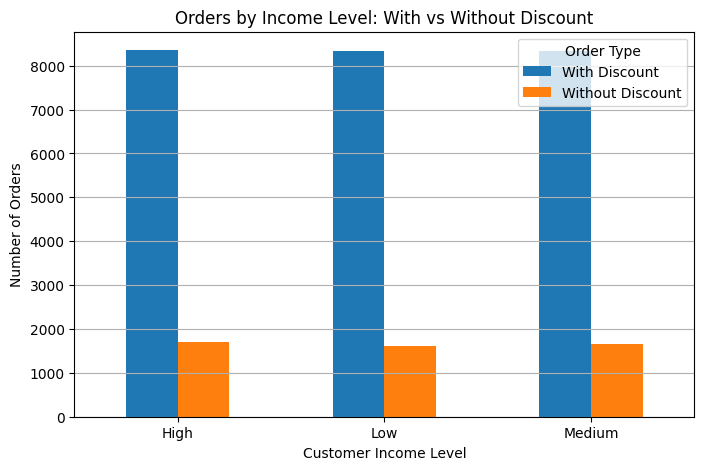

In [2]:
import matplotlib.pyplot as plt

# Step 1: Create discount flag (if not already)
df['discount_flag'] = df['discount_percent'].apply(
    lambda x: 'No Discount' if x == 0 else 'Discount'
)

# Step 2: Group by income level + discount
grouped = df.groupby(['customer_income_level', 'discount_flag'])['order_id'].count().reset_index()

# Step 3: Pivot for comparison
pivot_df = grouped.pivot(
    index='customer_income_level',
    columns='discount_flag',
    values='order_id'
).fillna(0)

# Step 4: Rename for clarity (optional)
pivot_df.rename(columns={
    'Discount': 'With Discount',
    'No Discount': 'Without Discount'
}, inplace=True)

# Step 5: Print table
print("\n📊 Orders by Income Level:\n")
print(pivot_df)

# Step 6: Plot
pivot_df[['With Discount', 'Without Discount']].plot(kind='bar', figsize=(8,5))

plt.xlabel('Customer Income Level')
plt.ylabel('Number of Orders')
plt.title('Orders by Income Level: With vs Without Discount')

plt.xticks(rotation=0)
plt.legend(title='Order Type')

plt.grid(axis='y')
plt.show()


📊 Orders by Country and Income Level:

customer_income_level  High Income  Low Income  Medium Income
country                                                      
Germany                       1656        1675           1634
India                         1699        1695           1597
Pakistan                      1663        1576           1602
UAE                           1688        1633           1797
UK                            1667        1726           1665
USA                           1686        1639           1702


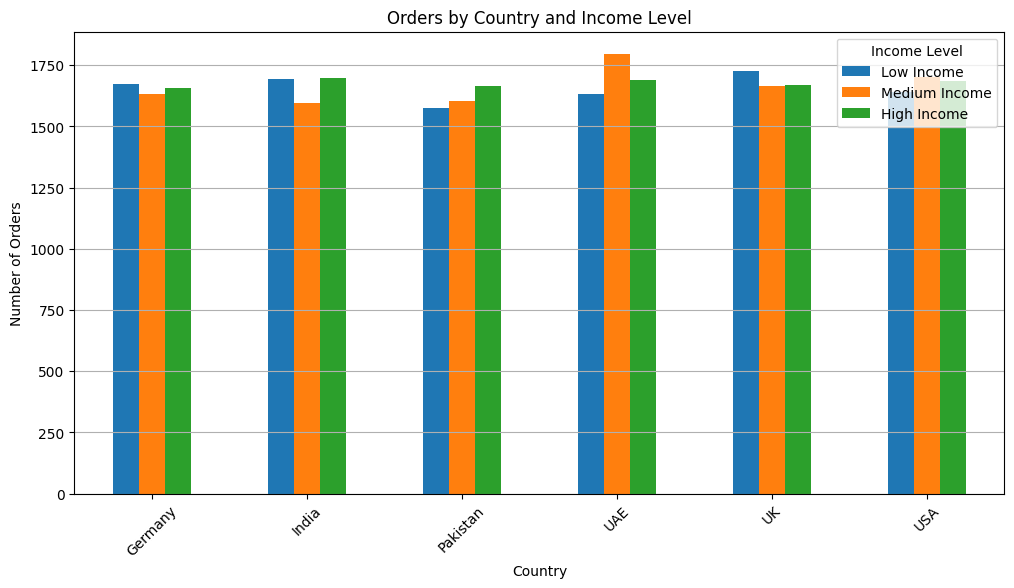

In [3]:
import matplotlib.pyplot as plt

# Step 1: Group by country + income level
grouped = df.groupby(['country', 'customer_income_level'])['order_id'].count().reset_index()

# Step 2: Pivot for comparison
pivot_df = grouped.pivot(
    index='country',
    columns='customer_income_level',
    values='order_id'
).fillna(0)

# Step 3: Rename columns (optional for clarity)
pivot_df.rename(columns={
    'Low': 'Low Income',
    'Medium': 'Medium Income',
    'High': 'High Income'
}, inplace=True)

# Step 4: Print table
print("\n📊 Orders by Country and Income Level:\n")
print(pivot_df)

# Step 5: Plot
pivot_df[['Low Income', 'Medium Income', 'High Income']].plot(kind='bar', figsize=(12,6))

plt.xlabel('Country')
plt.ylabel('Number of Orders')
plt.title('Orders by Country and Income Level')

plt.xticks(rotation=45)
plt.legend(title='Income Level')

plt.grid(axis='y')
plt.show()


📊 Orders by Sales Channel:

  sales_channel  order_count
0        Online        14991
1  Retail Store        15009


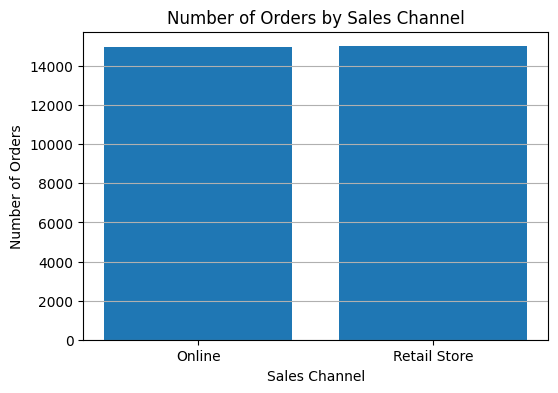

In [4]:
import matplotlib.pyplot as plt

# Step 1: Group by sales channel
grouped = df.groupby('sales_channel')['order_id'].count().reset_index()

# Step 2: Rename for clarity
grouped.rename(columns={'order_id': 'order_count'}, inplace=True)

# Step 3: Print table
print("\n📊 Orders by Sales Channel:\n")
print(grouped)

# Step 4: Plot
plt.figure(figsize=(6,4))

plt.bar(grouped['sales_channel'], grouped['order_count'])

plt.xlabel('Sales Channel')
plt.ylabel('Number of Orders')
plt.title('Number of Orders by Sales Channel')

plt.grid(axis='y')
plt.show()


📊 Orders by Country and Sales Channel:

sales_channel  Online Orders  Retail Orders
country                                    
Germany                 2503           2462
India                   2484           2507
Pakistan                2387           2454
UAE                     2562           2556
UK                      2537           2521
USA                     2518           2509


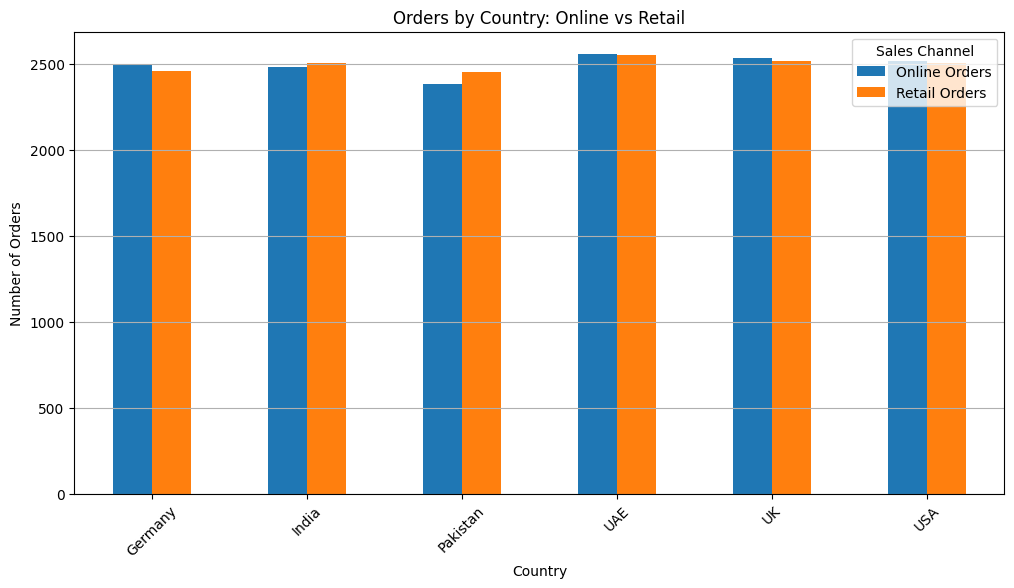

In [5]:
# Step 1: Group by sales channel + country
grouped = df.groupby(['country', 'sales_channel'])['order_id'].count().reset_index()

# Step 2: Pivot for comparison
pivot_df = grouped.pivot(
    index='country',
    columns='sales_channel',
    values='order_id'
).fillna(0)

# Step 3: Rename columns (optional)
pivot_df.rename(columns={
    'Online': 'Online Orders',
    'Retail Store': 'Retail Orders'
}, inplace=True)

# Step 4: Print table
print("\n📊 Orders by Country and Sales Channel:\n")
print(pivot_df)

# Step 5: Plot
pivot_df[['Online Orders', 'Retail Orders']].plot(kind='bar', figsize=(12,6))

plt.xlabel('Country')
plt.ylabel('Number of Orders')
plt.title('Orders by Country: Online vs Retail')

plt.xticks(rotation=45)
plt.legend(title='Sales Channel')

plt.grid(axis='y')
plt.show()


📊 Revenue by Brand in Each Country:

brand         ASICS     Adidas  New Balance       Nike       Puma    Reebok
country                                                                    
Germany   276872.50  242595.60    249740.25  251695.35  230696.15  252295.0
India     253626.95  262715.75    243659.10  244046.40  259834.15  257016.6
Pakistan  247418.40  235726.25    245229.50  248440.05  234172.90  255177.5
UAE       263693.30  245690.65    265464.45  246285.00  261323.85  263985.3
UK        253842.55  254239.30    249473.80  274344.45  259796.55  240603.4
USA       266008.80  245299.00    257834.40  259770.85  253271.30  229563.1


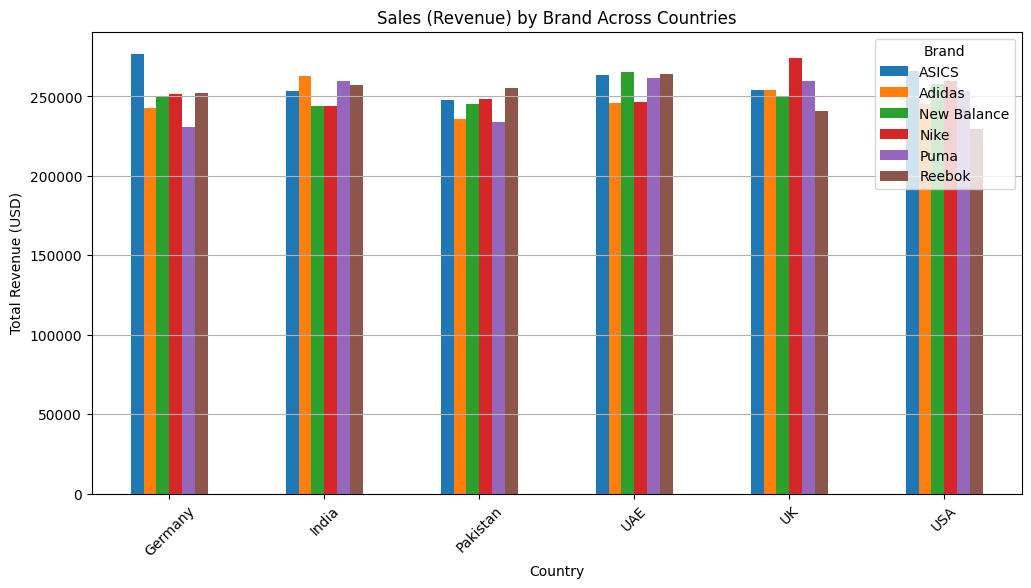

In [6]:
import matplotlib.pyplot as plt

# Step 1: Group by country + brand (use revenue for sales)
grouped = df.groupby(['country', 'brand'])['revenue_usd'].sum().reset_index()

# Step 2: Pivot for comparison
pivot_df = grouped.pivot(
    index='country',
    columns='brand',
    values='revenue_usd'
).fillna(0)

# Step 3: Print table
print("\n📊 Revenue by Brand in Each Country:\n")
print(pivot_df)

# Step 4: Plot
pivot_df.plot(kind='bar', figsize=(12,6))

plt.xlabel('Country')
plt.ylabel('Total Revenue (USD)')
plt.title('Sales (Revenue) by Brand Across Countries')

plt.xticks(rotation=45)
plt.legend(title='Brand')

plt.grid(axis='y')
plt.show()


📊 Number of Orders by Country:

    country  order_count
0   Germany         4965
1     India         4991
2  Pakistan         4841
3       UAE         5118
4        UK         5058
5       USA         5027


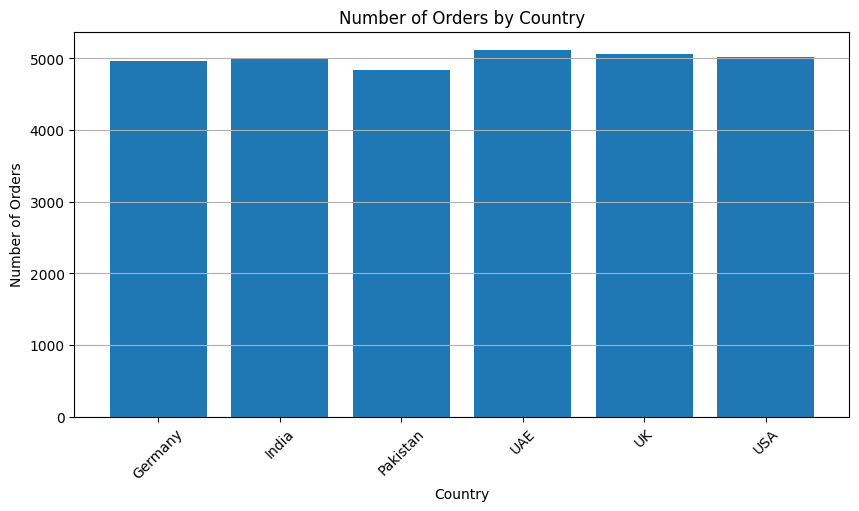

In [7]:
import matplotlib.pyplot as plt

# Step 1: Group by country
grouped = df.groupby('country')['order_id'].count().reset_index()

# Step 2: Rename column for clarity
grouped.rename(columns={'order_id': 'order_count'}, inplace=True)

# Step 3: Print table
print("\n📊 Number of Orders by Country:\n")
print(grouped)

# Step 4: Plot
plt.figure(figsize=(10,5))

plt.bar(grouped['country'], grouped['order_count'])

plt.xlabel('Country')
plt.ylabel('Number of Orders')
plt.title('Number of Orders by Country')

plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()


📊 Number of Orders by Brand in Each Country:

Brand     ASICS  Adidas  New Balance  Nike  Puma  Reebok
country                                                 
Germany     914     815          815   823   756     842
India       820     854          820   794   848     855
Pakistan    812     772          804   832   775     846
UAE         857     823          867   815   858     898
UK          842     829          843   893   832     819
USA         887     825          833   861   855     766


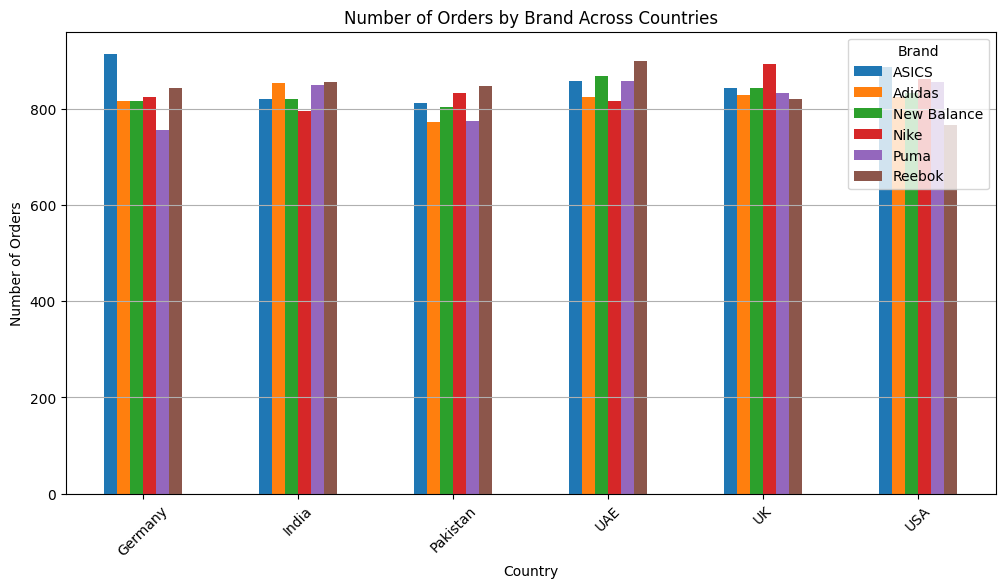

In [9]:
import matplotlib.pyplot as plt

# Step 1: Group by country + brand
grouped = df.groupby(['country', 'brand'])['order_id'].count().reset_index()

# Step 2: Pivot for comparison
pivot_df = grouped.pivot(
    index='country',
    columns='brand',
    values='order_id'
).fillna(0)

# Step 3: Rename column axis (optional)
pivot_df.columns.name = 'Brand'

# Step 4: Print table
print("\n📊 Number of Orders by Brand in Each Country:\n")
print(pivot_df)

# Step 5: Plot
pivot_df.plot(kind='bar', figsize=(12,6))

plt.xlabel('Country')
plt.ylabel('Number of Orders')
plt.title('Number of Orders by Brand Across Countries')

plt.xticks(rotation=45)
plt.legend(title='Brand')

plt.grid(axis='y')
plt.show()


📊 Number of Orders by Category in Each Country:

Category  Basketball   Gym  Lifestyle  Running  Training
country                                                 
Germany          992   963       1018     1009       983
India           1010   948       1027     1009       997
Pakistan         995   942        957      958       989
UAE             1063   991       1038     1026      1000
UK              1035  1025       1001     1004       993
USA              979   997       1018      977      1056


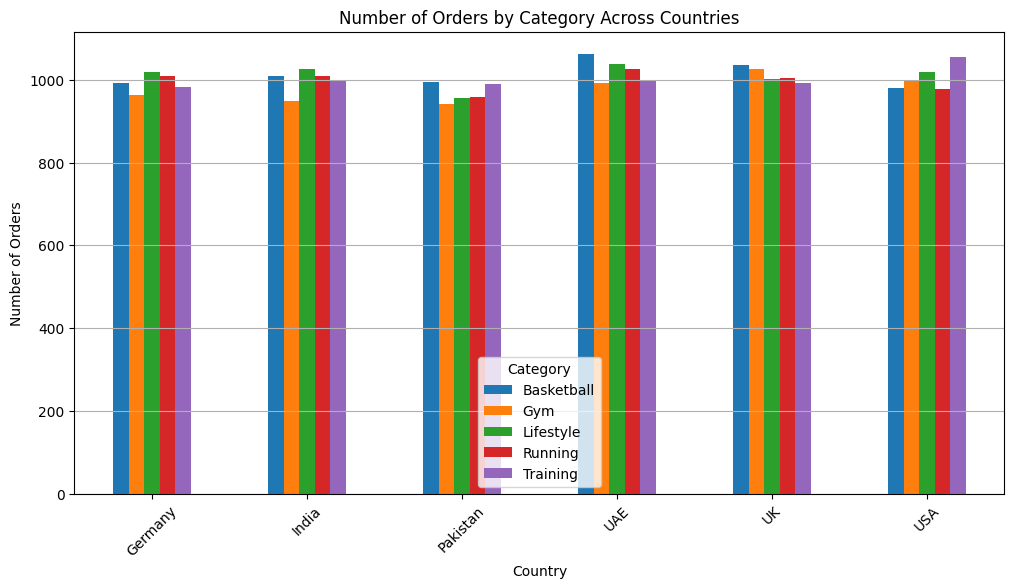

In [10]:
import matplotlib.pyplot as plt

# Step 1: Group by country + category
grouped = df.groupby(['country', 'category'])['order_id'].count().reset_index()

# Step 2: Pivot for comparison
pivot_df = grouped.pivot(
    index='country',
    columns='category',
    values='order_id'
).fillna(0)

# Step 3: Rename axis (optional)
pivot_df.columns.name = 'Category'

# Step 4: Print table
print("\n📊 Number of Orders by Category in Each Country:\n")
print(pivot_df)

# Step 5: Plot
pivot_df.plot(kind='bar', figsize=(12,6))

plt.xlabel('Country')
plt.ylabel('Number of Orders')
plt.title('Number of Orders by Category Across Countries')

plt.xticks(rotation=45)
plt.legend(title='Category')

plt.grid(axis='y')
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_6476\1660671764.py:5: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')



📊 Number of Orders per Month:

    month  order_count
0       1         2571
1       2         2312
2       3         2461
3       4         2473
4       5         2582
5       6         2488
6       7         2595
7       8         2524
8       9         2488
9      10         2533
10     11         2465
11     12         2508


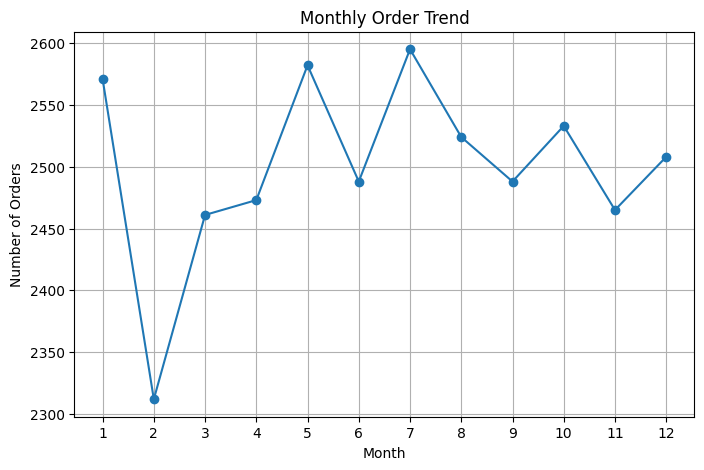

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Convert to datetime (IMPORTANT)
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

# Step 2: Extract month
df['month'] = df['order_date'].dt.month

# Step 3: Group by month
grouped = df.groupby('month')['order_id'].count().reset_index()

# Step 4: Rename column
grouped.rename(columns={'order_id': 'order_count'}, inplace=True)

# Step 5: Sort by month
grouped = grouped.sort_values(by='month')

# Step 6: Print table
print("\n📊 Number of Orders per Month:\n")
print(grouped)

# Step 7: Plot
plt.figure(figsize=(8,5))

plt.plot(grouped['month'], grouped['order_count'], marker='o')

plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.title('Monthly Order Trend')

plt.xticks(grouped['month'])
plt.grid()

plt.show()


📊 Orders per Month in Each Year:

     year  month  order_count
0    2018      1          303
1    2018      2          259
2    2018      3          283
3    2018      4          256
4    2018      5          294
..    ...    ...          ...
103  2026      8          274
104  2026      9          301
105  2026     10          261
106  2026     11          257
107  2026     12          275

[108 rows x 3 columns]


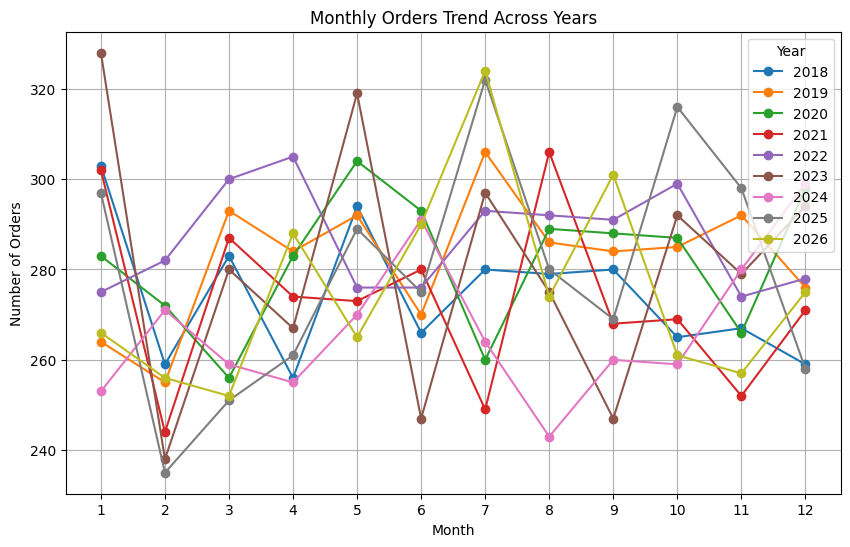

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Convert to datetime
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

# Step 2: Extract year and month
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month

# Step 3: Group by year + month
grouped = df.groupby(['year', 'month'])['order_id'].count().reset_index()

# Step 4: Rename column
grouped.rename(columns={'order_id': 'order_count'}, inplace=True)

# Step 5: Sort properly
grouped = grouped.sort_values(by=['year', 'month'])

# Step 6: Print table
print("\n📊 Orders per Month in Each Year:\n")
print(grouped)

# Step 7: Pivot for plotting
pivot_df = grouped.pivot(
    index='month',
    columns='year',
    values='order_count'
).fillna(0)

# Step 8: Plot
pivot_df.plot(kind='line', marker='o', figsize=(10,6))

plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.title('Monthly Orders Trend Across Years')

plt.xticks(range(1,13))
plt.legend(title='Year')

plt.grid()
plt.show()


📊 Average Orders per Month:

    month  avg_orders
0       1  285.666667
1       2  256.888889
2       3  273.444444
3       4  274.777778
4       5  286.888889
5       6  276.444444
6       7  288.333333
7       8  280.444444
8       9  276.444444
9      10  281.444444
10     11  273.888889
11     12  278.666667


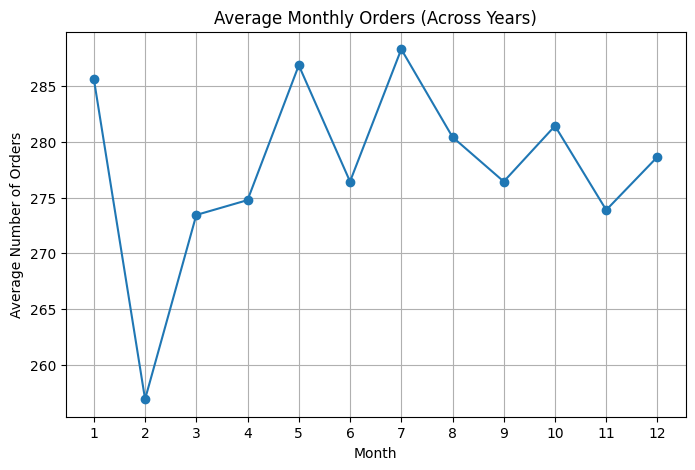

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Convert to datetime
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

# Step 2: Extract year and month
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month

# Step 3: Count orders per year-month
monthly_orders = df.groupby(['year', 'month'])['order_id'].count().reset_index()

# Step 4: Calculate average across years
avg_monthly = monthly_orders.groupby('month')['order_id'].mean().reset_index()

# Step 5: Rename column
avg_monthly.rename(columns={'order_id': 'avg_orders'}, inplace=True)

# Step 6: Sort
avg_monthly = avg_monthly.sort_values(by='month')

# Step 7: Print table
print("\n📊 Average Orders per Month:\n")
print(avg_monthly)

# Step 8: Plot
plt.figure(figsize=(8,5))

plt.plot(avg_monthly['month'], avg_monthly['avg_orders'], marker='o')

plt.xlabel('Month')
plt.ylabel('Average Number of Orders')
plt.title('Average Monthly Orders (Across Years)')

plt.xticks(avg_monthly['month'])
plt.grid()

plt.show()

In [15]:
!pip install scipy


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import pandas as pd
from scipy.stats import ttest_ind

# Step 1: Ensure datetime
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

# Step 2: Extract year & month
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month

# Step 3: Orders per (year, month)
year_month_orders = df.groupby(['year', 'month'])['order_id'].count().reset_index()

# Step 4: Separate February vs Other Months
feb_orders = year_month_orders[year_month_orders['month'] == 2]['order_id']
other_orders = year_month_orders[year_month_orders['month'] != 2]['order_id']

print("\nMean Feb Orders:", feb_orders.mean())
print("Mean Other Months:", other_orders.mean())
print("Sample size Feb:", len(feb_orders))
print("Sample size Others:", len(other_orders))

# Step 5: Perform Independent t-test (one-sided)
t_stat, p_value = ttest_ind(feb_orders, other_orders, alternative='less')

print("T-statistic:", t_stat)
print("P-value:", p_value)

# Step 6: Interpretation
alpha = 0.05

if p_value < alpha:
    print("\nReject Null Hypothesis (H0)")
    print("➡ February has significantly lower orders than other months")
else:
    print("\nFail to Reject Null Hypothesis (H0)")
    print("➡ No significant difference for February")


Mean Feb Orders: 256.8888888888889
Mean Other Months: 279.67676767676767
Sample size Feb: 9
Sample size Others: 99
T-statistic: -3.5662344428150745
P-value: 0.0002724910235459078

Reject Null Hypothesis (H0)
➡ February has significantly lower orders than other months


In [17]:
import pandas as pd
from scipy.stats import ttest_ind

# Step 1: Ensure datetime
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

# Step 2: Extract year & month
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month

# Step 3: Orders per (year, month)
year_month_orders = df.groupby(['year', 'month'])['order_id'].count().reset_index()

# Step 4: Separate February vs Other Months
feb_orders = year_month_orders[year_month_orders['month'] == 2]['order_id']
other_orders = year_month_orders[year_month_orders['month'] != 2]['order_id']

# Step 5: Welch’s t-test (better)
t_stat, p_value = ttest_ind(
    feb_orders,
    other_orders,
    equal_var=False,        # ✅ important fix
    alternative='less'
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

# Step 6: Interpretation
alpha = 0.05

if p_value < alpha:
    print("\nReject Null Hypothesis (H0)")
    print("➡ February has significantly lower orders than other months")
else:
    print("\nFail to Reject Null Hypothesis (H0)")
    print("➡ No significant difference for February")

T-statistic: -4.015732911456923
P-value: 0.001219041068848128

Reject Null Hypothesis (H0)
➡ February has significantly lower orders than other months
